In [10]:
%reload_ext autoreload
from functions_v2 import *

In [12]:
from tqdm import tqdm

In [14]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt

In [16]:
edges, n_vertices, edge_weights = load_graph("../summer-project/power-US-Grid.mtx")

✓ Loaded: ../summer-project/power-US-Grid.mtx
  Vertices : 4941
  Edges    : 6594
  Weighted : no



In [18]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 4941 x 4941
  Degree range: [1, 19]
  Non-zeros in L: 18129



In [14]:
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ lambda_min = 0.000271
  (eigenvalues found: [0.         0.00027102])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)



In [16]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.1054, 0.1071]



In [34]:
k = compute_permeability(u, edges, edge_weights)

In [24]:
G_nx_power = nx.Graph()
G_nx_power.add_nodes_from(range(n_vertices))
G_nx_power.add_edges_from(edges)
print(f"NetworkX graph built: {G_nx_power.number_of_nodes()} nodes, {G_nx_power.number_of_edges()} edges")

NetworkX graph built: 4941 nodes, 6594 edges


In [36]:
# weighted laplacian 
L_k = build_weighted_laplacian(edges, n_vertices, k)

In [38]:
p  = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

In [60]:
np.random.seed(42)
Q_samples = monte_carlo_loop_tqdm(L_sigma, lambda_min, edges, n_vertices,
                          gamma_in, gamma_out, edge_weights=None,
                          N=1500, use_amg=False)

Monte Carlo:   0%|          | 0/1500 [00:00<?, ?sample/s]


✓ Done — 1500 samples
  Mean Q : 0.152135
  Std Q  : 0.001508



=== Monte Carlo Results ===
  Samples : 1500
  Mean Q  : 0.152135
  Std Q   : 0.001508
  Var Q   : 0.000002
  Min Q   : 0.147350
  Max Q   : 0.157552
Saved as uspowergrid_phase7.png


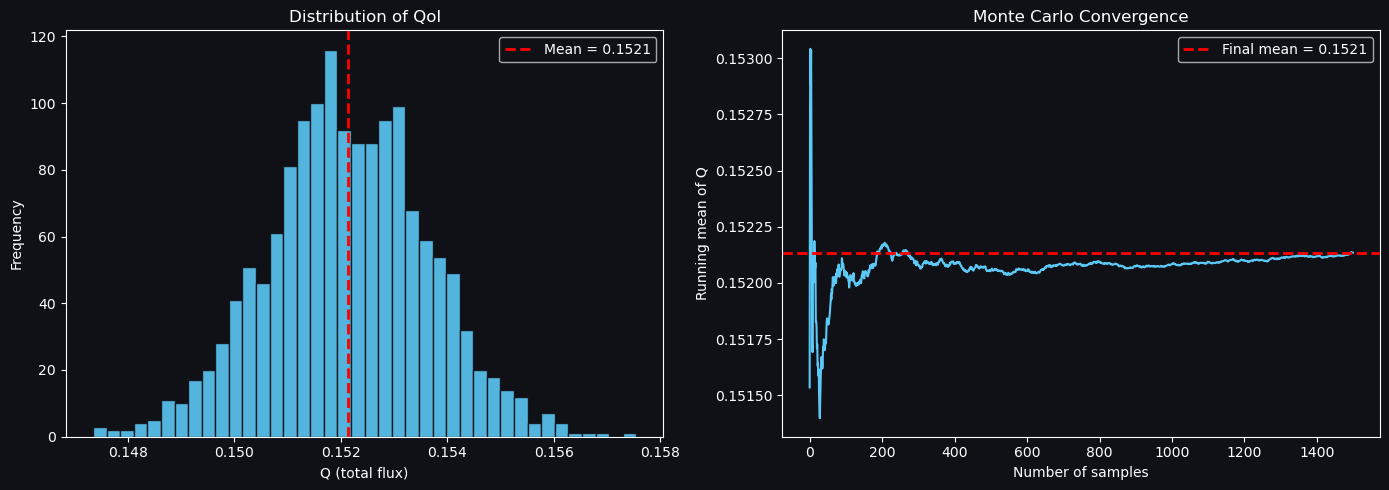

In [62]:
analyze_qoi(Q_samples, save_as="uspowergrid_phase7.png" )

In [89]:
gamma_in_set = set(gamma_in)
inlet_edges_powergrid = [(i,j) for i,j in edges if i in gamma_in_set or j in gamma_in_set]
print(f"US Power Grid — gamma_in size: {len(gamma_in)}")
print(f"US Power Grid — edges touching gamma_in: {len(inlet_edges_powergrid)}")

US Power Grid — gamma_in size: 23
US Power Grid — edges touching gamma_in: 81


In [83]:
# make sure edges, gamma_out are the Power Grid versions (reload if needed)
gamma_out_set = set(gamma_out)
outlet_edges_powergrid = [(i,j) for i,j in edges if i in gamma_out_set or j in gamma_out_set]
print(f"US Power Grid — gamma_out size: {len(gamma_out)}")
print(f"US Power Grid — edges touching gamma_out: {len(outlet_edges_powergrid)}")
print(f"US Power Grid — normalized Q: {3.62 / len(outlet_edges_powergrid):.4f}")

US Power Grid — gamma_out size: 14
US Power Grid — edges touching gamma_out: 23
US Power Grid — normalized Q: 0.1574


# community detection

In [20]:
# build networkx graph for power grid
G_nx_power = nx.Graph()
G_nx_power.add_nodes_from(range(n_vertices))
G_nx_power.add_edges_from(edges)

# use greedy modularity — power grid is 4941 nodes, should be fast enough
communities_power = list(nx.community.greedy_modularity_communities(G_nx_power))

print(f"Number of communities: {len(communities_power)}")
for i, c in enumerate(communities_power):
    print(f"  Community {i}: {len(c)} vertices, "
          f"avg degree = {np.mean([dict(G_nx_power.degree())[v] for v in c]):.2f}")

Number of communities: 43
  Community 0: 279 vertices, avg degree = 2.63
  Community 1: 245 vertices, avg degree = 2.95
  Community 2: 229 vertices, avg degree = 2.79
  Community 3: 223 vertices, avg degree = 2.36
  Community 4: 200 vertices, avg degree = 2.37
  Community 5: 198 vertices, avg degree = 2.79
  Community 6: 197 vertices, avg degree = 2.47
  Community 7: 197 vertices, avg degree = 2.48
  Community 8: 193 vertices, avg degree = 3.04
  Community 9: 184 vertices, avg degree = 2.58
  Community 10: 173 vertices, avg degree = 2.49
  Community 11: 164 vertices, avg degree = 2.45
  Community 12: 155 vertices, avg degree = 2.57
  Community 13: 153 vertices, avg degree = 2.99
  Community 14: 150 vertices, avg degree = 2.69
  Community 15: 140 vertices, avg degree = 3.04
  Community 16: 132 vertices, avg degree = 2.67
  Community 17: 131 vertices, avg degree = 2.71
  Community 18: 120 vertices, avg degree = 2.81
  Community 19: 120 vertices, avg degree = 2.24
  Community 20: 114 vert

C:\Users\Rakesh\AppData\Local\Temp\ipykernel_3412\3403018567.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab20', len(communities_power))


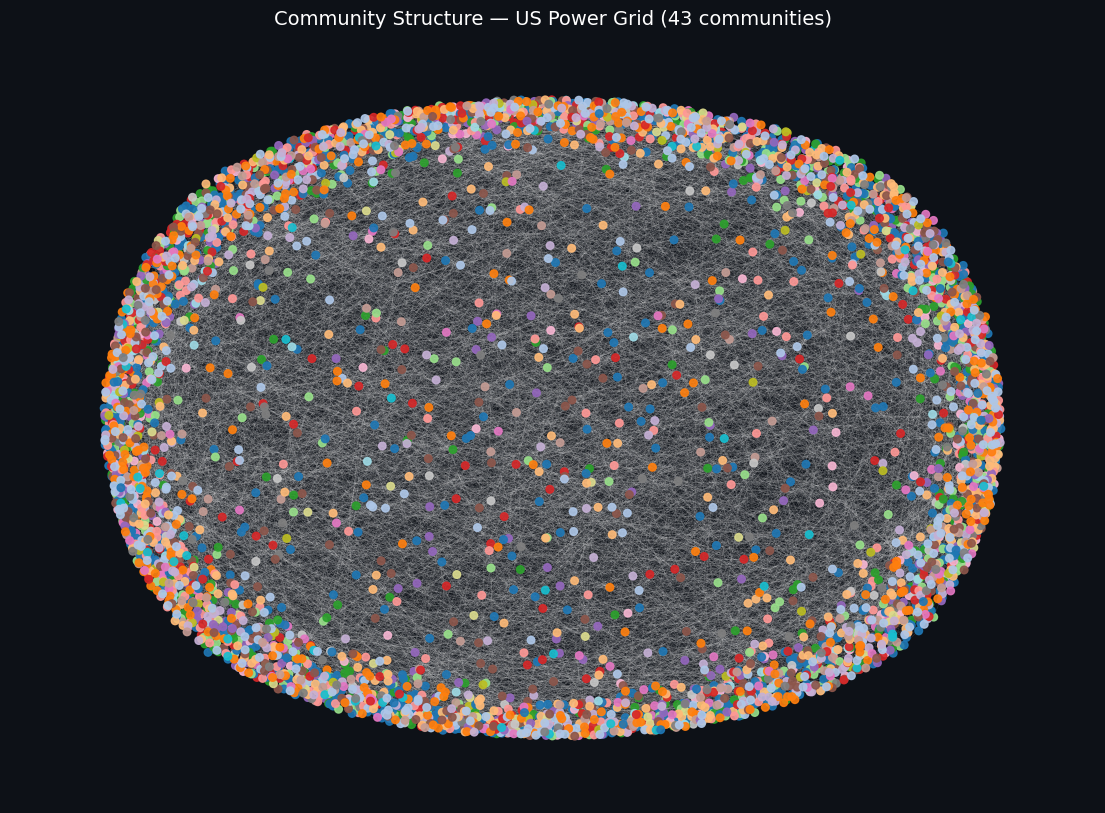

In [22]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# assign a color to each community
cmap = cm.get_cmap('tab20', len(communities_power))
node_colors = {}
for i, c in enumerate(communities_power):
    for v in c:
        node_colors[v] = cmap(i)

color_list = [node_colors[v] for v in G_nx_power.nodes()]
pos = nx.spring_layout(G_nx_power, seed=42, k=0.5)

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

nx.draw_networkx_edges(G_nx_power, pos, ax=ax, edge_color='white',
                       width=0.3, alpha=0.15)
nx.draw_networkx_nodes(G_nx_power, pos, ax=ax, node_color=color_list,
                       node_size=30, alpha=0.9)

ax.set_title(f'Community Structure — US Power Grid ({len(communities_power)} communities)',
             color='white', fontsize=14)
ax.axis('off')
plt.savefig('power_grid_communities.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

In [31]:
def community_clustered_layout(G, communities, community_k=2.0, node_k_scale=1.0, seed=42):
    n_comm = len(communities)
    node_to_comm = {}
    for i, c in enumerate(communities):
        for v in c:
            node_to_comm[v] = i

    comm_graph = nx.Graph()
    comm_graph.add_nodes_from(range(n_comm))
    for u, v in G.edges():
        cu, cv = node_to_comm[u], node_to_comm[v]
        if cu != cv:
            w = comm_graph[cu][cv]['weight'] + 1 if comm_graph.has_edge(cu, cv) else 1
            comm_graph.add_edge(cu, cv, weight=w)

    comm_pos = nx.spring_layout(comm_graph, k=community_k, seed=seed,
                                  iterations=200, weight='weight')

    comm_pos_arr = np.array([comm_pos[i] for i in range(n_comm)])
    comm_pos_arr -= comm_pos_arr.mean(axis=0)
    max_extent = np.abs(comm_pos_arr).max()
    if max_extent > 0:
        comm_pos_arr = comm_pos_arr / max_extent * 3.0
    comm_pos = {i: comm_pos_arr[i] for i in range(n_comm)}

    pos = {}
    for i, c in enumerate(communities):
        sub = G.subgraph(c)
        k_val = node_k_scale / np.sqrt(max(len(c), 1))
        sub_pos = nx.spring_layout(sub, k=k_val, seed=seed + i, iterations=50)
        cx, cy = comm_pos[i]
        radius = 0.25 * np.sqrt(len(c))
        for v, (x, y) in sub_pos.items():
            pos[v] = (cx + x * radius, cy + y * radius)

    return pos


def plot_community_structure(G, communities, title="Community Structure",
                               save_as=None, node_size=30, edge_alpha=0.12,
                               community_k=2.0):
    pos = community_clustered_layout(G, communities, community_k=community_k)

    cmap = plt.colormaps.get_cmap('tab20').resampled(len(communities))
    node_colors = {}
    for i, c in enumerate(communities):
        for v in c:
            node_colors[v] = cmap(i)
    color_list = [node_colors[v] for v in G.nodes()]

    fig, ax = plt.subplots(figsize=(14, 10))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='white',
                            width=0.3, alpha=edge_alpha)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color_list,
                            node_size=node_size, alpha=0.9)
    ax.set_title(f'{title} ({len(communities)} communities)',
                 color='white', fontsize=14)
    ax.axis('off')

    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight', facecolor='#0d1117')
        print(f"✓ Saved: {save_as}")

    plt.show()

✓ Saved: power_grid_communities.png


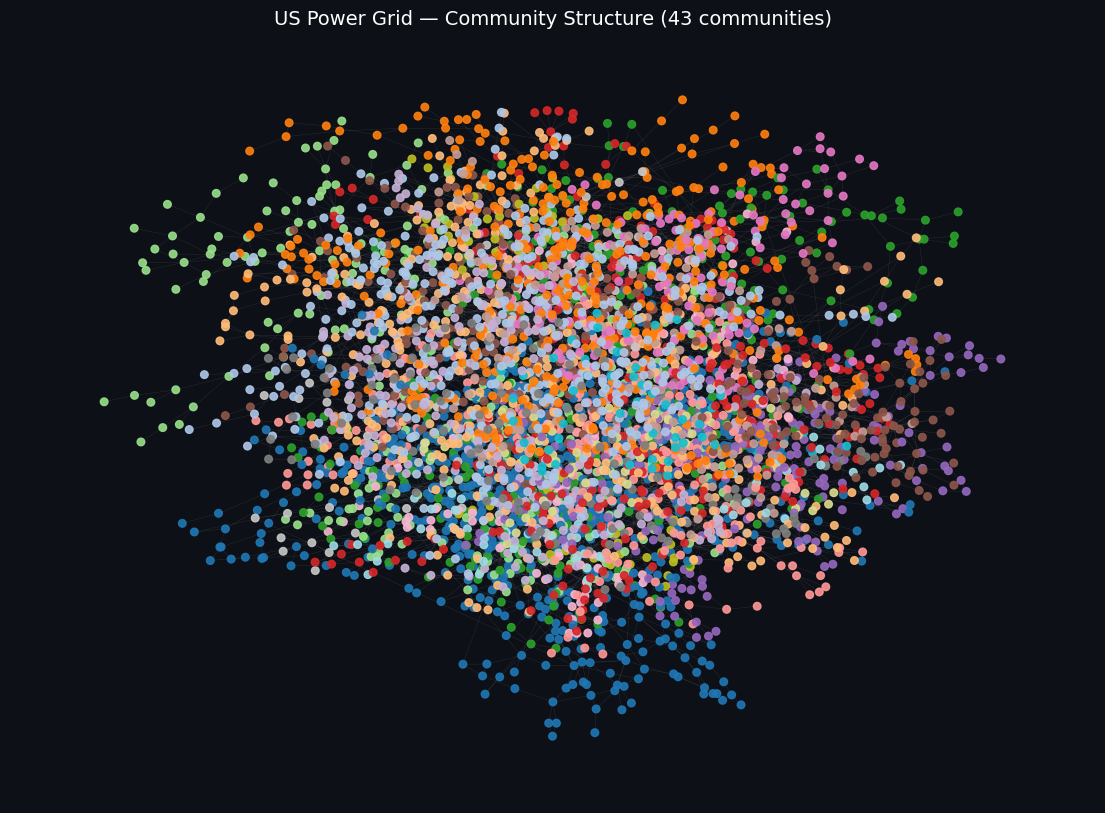

In [35]:
communities_sorted = sorted(communities_power, key=len, reverse=True)

plot_community_structure(
    G_nx_power, communities_sorted,
    title="US Power Grid — Community Structure",
    save_as="power_grid_communities.png",
    community_k=2.0
)

In [37]:
import networkx as nx

# modularity score tells you how "real" the community split actually is
# (0 = no better than random grouping, closer to 1 = strong, clean community structure)
modularity = nx.algorithms.community.modularity(G_nx_power, communities_power)
print(f"Modularity: {modularity:.4f}")

# also worth checking: how many edges are WITHIN communities vs BETWEEN them
communities_sorted = sorted(communities_power, key=len, reverse=True)
node_to_comm = {v: i for i, c in enumerate(communities_sorted) for v in c}
within = sum(1 for u, v in G_nx_power.edges() if node_to_comm[u] == node_to_comm[v])
between = G_nx_power.number_of_edges() - within
print(f"Within-community edges: {within} ({within/G_nx_power.number_of_edges()*100:.1f}%)")
print(f"Between-community edges: {between} ({between/G_nx_power.number_of_edges()*100:.1f}%)")

Modularity: 0.9346
Within-community edges: 6377 (96.7%)
Between-community edges: 217 (3.3%)


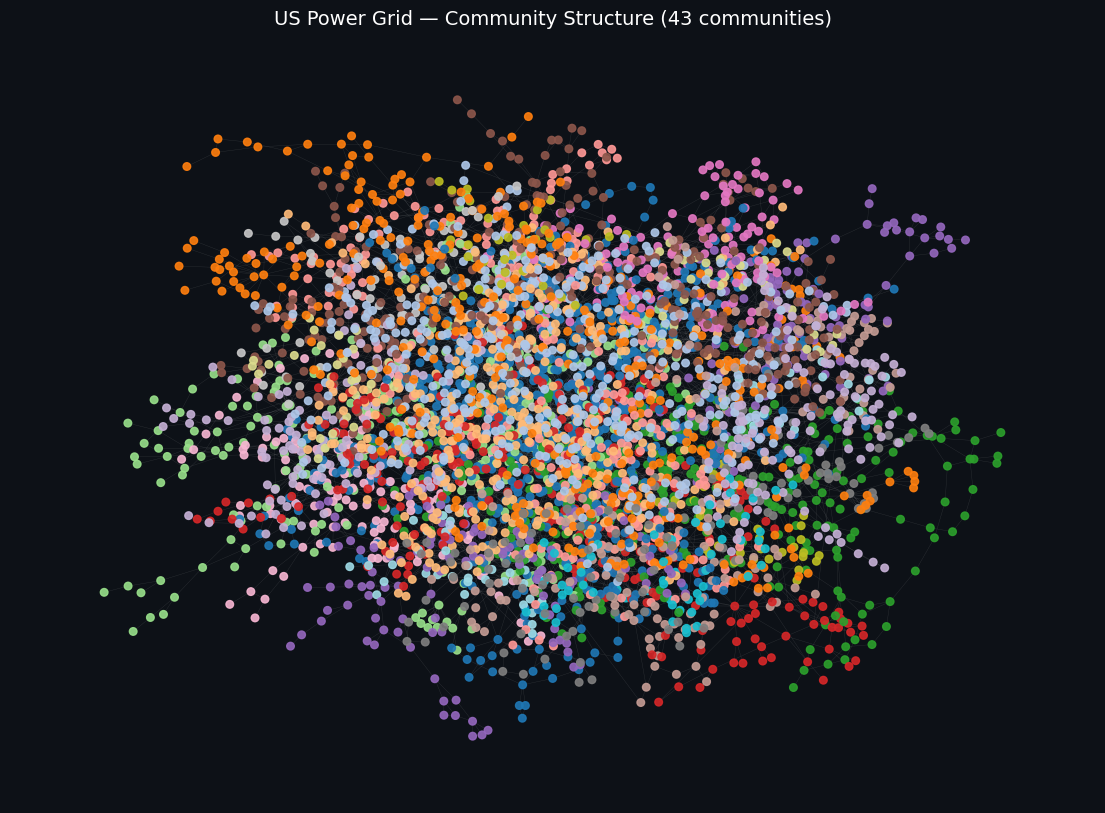

In [39]:
plot_community_structure(G_nx_power, communities_sorted, 
                          title="US Power Grid — Community Structure",
                          community_k=8.0)  # push this much higher

[279, 245, 229, 223, 200, 198, 197, 197, 193, 184, 173, 164, 155, 153, 150, 140, 132, 131, 120, 120, 114, 112, 109, 105, 104, 78, 74, 72, 66, 63, 62, 61, 58, 42, 33, 32, 31, 31, 30, 26, 19, 18, 18]
✓ Saved: power_grid_communities_topN.png


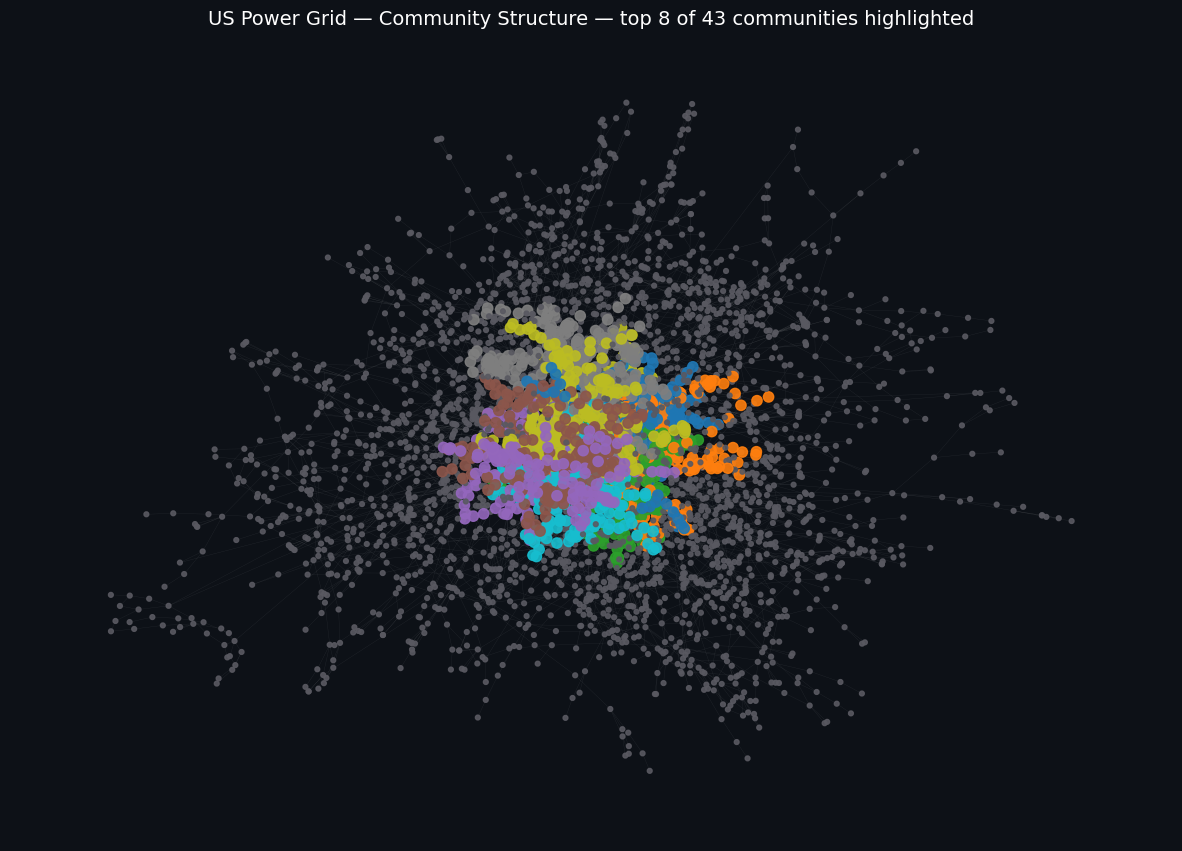

In [45]:
communities_sorted = sorted(communities_power, key=len, reverse=True)
print([len(c) for c in communities_sorted])  # glance at sizes to pick a sensible top_n

plot_community_topN(
    G_nx_power, communities_sorted,
    top_n=8,  # try 6-10, adjust based on how many "large" communities you actually have
    community_k=5.0,
    title="US Power Grid — Community Structure",
    save_as="power_grid_communities_topN.png"
)

In [43]:
def community_clustered_layout(G, communities, community_k=2.0, node_k_scale=1.0, seed=42):
    """
    Two-level layout that visually groups communities together.
    1. Builds a coarse community graph and lays it out with spring_layout
       to get a "center" position for each community.
    2. Lays out each community's own nodes with their own spring_layout,
       then places that cluster around its community's center.
    """
    n_comm = len(communities)
    node_to_comm = {}
    for i, c in enumerate(communities):
        for v in c:
            node_to_comm[v] = i

    comm_graph = nx.Graph()
    comm_graph.add_nodes_from(range(n_comm))
    for u, v in G.edges():
        cu, cv = node_to_comm[u], node_to_comm[v]
        if cu != cv:
            w = comm_graph[cu][cv]['weight'] + 1 if comm_graph.has_edge(cu, cv) else 1
            comm_graph.add_edge(cu, cv, weight=w)

    comm_pos = nx.spring_layout(comm_graph, k=community_k, seed=seed,
                                  iterations=200, weight='weight')

    comm_pos_arr = np.array([comm_pos[i] for i in range(n_comm)])
    comm_pos_arr -= comm_pos_arr.mean(axis=0)
    max_extent = np.abs(comm_pos_arr).max()
    if max_extent > 0:
        comm_pos_arr = comm_pos_arr / max_extent * 3.0
    comm_pos = {i: comm_pos_arr[i] for i in range(n_comm)}

    pos = {}
    for i, c in enumerate(communities):
        sub = G.subgraph(c)
        k_val = node_k_scale / np.sqrt(max(len(c), 1))
        sub_pos = nx.spring_layout(sub, k=k_val, seed=seed + i, iterations=50)
        cx, cy = comm_pos[i]
        radius = 0.25 * np.sqrt(len(c))
        for v, (x, y) in sub_pos.items():
            pos[v] = (cx + x * radius, cy + y * radius)

    return pos


def plot_community_topN(G, communities, top_n=8, community_k=5.0,
                          title="Community Structure", save_as=None,
                          highlight_size=55, background_size=12,
                          edge_alpha=0.08):
    """
    Highlights only the top_n largest communities in distinct colors;
    everything else is shown as small gray background points for context.

    Parameters
    ----------
    G              : networkx.Graph
    communities    : list of sets, SORTED LARGEST FIRST
                      (e.g. sorted(communities, key=len, reverse=True))
    top_n          : how many communities to highlight distinctly
    community_k    : spacing between community clusters — increase if
                      highlighted communities visually overlap
    title          : plot title
    save_as        : filepath to save, or None
    highlight_size : marker size for highlighted community nodes
    background_size: marker size for grayed-out "other" nodes
    edge_alpha     : edge transparency
    """
    top = communities[:top_n]
    rest = communities[top_n:]
    rest_merged = set().union(*rest) if rest else set()
    all_groups = top + ([rest_merged] if rest_merged else [])

    pos = community_clustered_layout(G, all_groups, community_k=community_k)

    cmap = plt.colormaps.get_cmap('tab10').resampled(top_n)
    node_colors = {}
    for i, c in enumerate(top):
        for v in c:
            node_colors[v] = cmap(i)
    for v in rest_merged:
        node_colors[v] = (0.35, 0.35, 0.38, 0.6)

    color_list = [node_colors[v] for v in G.nodes()]
    size_list = [highlight_size if v not in rest_merged else background_size
                 for v in G.nodes()]

    fig, ax = plt.subplots(figsize=(15, 10.5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='white',
                            width=0.3, alpha=edge_alpha)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color_list,
                            node_size=size_list, alpha=0.9)
    ax.set_title(f'{title} — top {top_n} of {len(communities)} communities highlighted',
                 color='white', fontsize=14)
    ax.axis('off')

    if save_as:
        plt.savefig(save_as, dpi=150, bbox_inches='tight', facecolor='#0d1117')
        print(f"✓ Saved: {save_as}")

    plt.show()

In [ ]:
import networkx as nx
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix

def find_diameter_endpoints(G_nx, n_sample=5):
    """
    Find approximate diameter endpoints using double BFS.
    
    Step 1: Start from arbitrary vertex, find furthest vertex v
    Step 2: From v, find furthest vertex w  
    Step 3: v and w are approximate diameter endpoints
    
    n_sample: run from multiple start points and pick best pair
    """
    best_dist = 0
    best_v, best_w = None, None
    
    # sample a few starting points for robustness
    start_nodes = list(G_nx.nodes())[:n_sample]
    
    for start in start_nodes:
        # first BFS
        lengths = nx.single_source_shortest_path_length(G_nx, start)
        v = max(lengths, key=lengths.get)
        
        # second BFS from v
        lengths_v = nx.single_source_shortest_path_length(G_nx, v)
        w = max(lengths_v, key=lengths_v.get)
        dist = lengths_v[w]
        
        if dist > best_dist:
            best_dist = dist
            best_v, best_w = v, w
    
    return best_v, best_w, best_dist


# find diameter endpoints
v, w, diameter = find_diameter_endpoints(G_nx_power)
print(f"Diameter endpoints: vertex {v} and vertex {w}")
print(f"Shortest path between them: {diameter} hops")

# define gamma_in and gamma_out as k-hop neighborhoods
k = 2  # include vertices within k hops of each endpoint

gamma_in  = set([v]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, v, cutoff=k).keys())
gamma_out = set([w]) | set(nx.single_source_shortest_path_length(
                            G_nx_power, w, cutoff=k).keys())

# remove overlap before converting to list
gamma_in  = gamma_in  - gamma_out
gamma_out = gamma_out - gamma_in

# now convert to list
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"\ngamma_in  : {len(gamma_in)} vertices (neighborhood of vertex {v})")
print(f"gamma_out : {len(gamma_out)} vertices (neighborhood of vertex {w})")
print(f"Flow must travel ~{diameter} hops from inlet to outlet")

In [ ]:
for k in [1, 2, 3, 4, 5]:
    gin  = set(nx.single_source_shortest_path_length(G_nx_power, v, cutoff=k).keys())
    gout = set(nx.single_source_shortest_path_length(G_nx_power, w, cutoff=k).keys())
    gin  = gin - gout
    gout = gout - gin
    print(f"k={k}: gamma_in={len(gin)}, gamma_out={len(gout)}")

In [ ]:
k = 4
gamma_in  = set(nx.single_source_shortest_path_length(G_nx_power, v, cutoff=k).keys())
gamma_out = set(nx.single_source_shortest_path_length(G_nx_power, w, cutoff=k).keys())
gamma_in  = gamma_in - gamma_out
gamma_out = gamma_out - gamma_in
gamma_in  = list(gamma_in)
gamma_out = list(gamma_out)

print(f"gamma_in  : {len(gamma_in)} vertices")
print(f"gamma_out : {len(gamma_out)} vertices")

## Where `b` (rhs) comes from in solve_darcy

```python
rhs = -L_k[interior, :][:, list(boundary)] @ p_boundary[list(boundary)]
```

1. `L_k[interior, :][:, list(boundary)]` → the **L_ib block**: interior rows, boundary columns. Captures how strongly each interior node connects to each boundary node.
2. `p_boundary[list(boundary)]` → the known fixed pressures (p_in / p_out) at just the boundary nodes, in matching order.
3. Multiply: for each interior node, sums (edge weight × neighbor's fixed pressure) over its boundary neighbors. Interior nodes with no boundary neighbor get 0.
4. Negate: comes from rearranging `L_k @ p = 0` → `L_ii p_i = -L_ib p_b`. Moves the known boundary term to the right-hand side.

**Result:** `b` is a vector over interior nodes only — nonzero just where an interior node directly touches `gamma_in`/`gamma_out`, zero elsewhere.

**Note:** `list(boundary)` is called twice (once per slice) — safe since Python sets keep consistent iteration order within a session, but assign it to a variable once if you want to remove any doubt.